In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("data.csv", encoding='latin1')

# Data Overview

In [3]:

data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
data.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 173.1 MB


## Data type optimization

In [6]:
data = data.astype(
    {
        "Quantity": "Int32",
        "UnitPrice": 'Float32',
        'CustomerID': 'Int32',
        'InvoiceNo': 'category',
        'StockCode': 'category',
        'Description': 'category',
        'Country': 'category',
        'InvoiceDate': 'datetime64[ns]'
    }
)

## Optimization check

In [7]:
data.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  category      
 1   StockCode    541909 non-null  category      
 2   Description  540455 non-null  category      
 3   Quantity     541909 non-null  Int32         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  Float32       
 6   CustomerID   406829 non-null  Int32         
 7   Country      541909 non-null  category      
dtypes: Float32(1), Int32(2), category(4), datetime64[ns](1)
memory usage: 17.4 MB


## Data Cleaning
### Missing values check

In [8]:
data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Adding new category for missing values replacing

In [9]:
data['Description'] = data['Description'].cat.add_categories('Unknown')

### Missing product descriptions were replaced with "Unknown" to ensure consistency in product-level analysis.

In [10]:
data['Description'] = data['Description'].fillna('Unknown')

In [11]:
data.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Negative quantity overview
### Negative values reflect return transactions

In [12]:
data[data['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.5,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.690002,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


## Feature Engineering
### A TransactionType coulumn was created for transaction types from negative & positive quantity. A return flag was added to identify return transactions

In [13]:
data['TransactionType'] = data['Quantity'].apply(
    lambda x: 'Return' if x < 0 else 'Sale'
)

data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Sale
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Sale
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale


### Negative unitprice overview
#### Negative vales seems to be data error - the price cannot be negative

In [14]:
data[data['UnitPrice'] < -0.00001]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.05957,<NA>,United Kingdom,Sale
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.05957,<NA>,United Kingdom,Sale


### Negative values were removed for UnitPrice column

In [15]:
data = data[data['UnitPrice'] > -0.00001]

data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Sale
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Sale
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,Sale
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.1,12680,France,Sale
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,Sale
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,Sale


### 2515 transactions with zero price detected. These are likely promotional items, system adjustments, or data inconsistencies

In [16]:
data[data['UnitPrice'] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType
622,536414,22139,Unknown,56,2010-12-01 11:52:00,0.0,<NA>,United Kingdom,Sale
1970,536545,21134,Unknown,1,2010-12-01 14:32:00,0.0,<NA>,United Kingdom,Sale
1971,536546,22145,Unknown,1,2010-12-01 14:33:00,0.0,<NA>,United Kingdom,Sale
1972,536547,37509,Unknown,1,2010-12-01 14:33:00,0.0,<NA>,United Kingdom,Sale
1987,536549,85226A,Unknown,1,2010-12-01 14:34:00,0.0,<NA>,United Kingdom,Sale
...,...,...,...,...,...,...,...,...,...
536981,581234,72817,Unknown,27,2011-12-08 10:33:00,0.0,<NA>,United Kingdom,Sale
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,<NA>,United Kingdom,Sale
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,<NA>,United Kingdom,Sale
538554,581408,85175,Unknown,20,2011-12-08 14:06:00,0.0,<NA>,United Kingdom,Sale


### A FreeFlag column was created to reflect 0 UnitPrice

In [17]:
data['FreeFlag'] = data['UnitPrice'].apply(
    lambda x: 'Free' if x == 0 else 'Paid'
)

data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,FreeFlag
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Sale,Paid
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Sale,Paid
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid


### Calculated revenue per transaction line (Quantity × UnitPrice)

In [18]:
data['Revenue'] = data['Quantity'] * data['UnitPrice']

data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,FreeFlag,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Sale,Paid,15.3
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Sale,Paid,22.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001


### A year_month column was created to reflect month of year

In [19]:
data['year_month'] = data['InvoiceDate'].dt.to_period('M')

data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,FreeFlag,Revenue,year_month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Sale,Paid,15.3,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Sale,Paid,22.0,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001,2010-12
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,Sale,Paid,10.2,2011-12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.1,12680,France,Sale,Paid,12.599999,2011-12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,Sale,Paid,16.6,2011-12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,Sale,Paid,16.6,2011-12


### A day_of_week column was created to analyze weekly patterns in revenue.

In [20]:
data['day_of_week'] = data['InvoiceDate'].dt.day_name()

data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,FreeFlag,Revenue,year_month,day_of_week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Sale,Paid,15.3,2010-12,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001,2010-12,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Sale,Paid,22.0,2010-12,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001,2010-12,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001,2010-12,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,Sale,Paid,10.2,2011-12,Friday
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.1,12680,France,Sale,Paid,12.599999,2011-12,Friday
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,Sale,Paid,16.6,2011-12,Friday
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,Sale,Paid,16.6,2011-12,Friday


In [21]:
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

# Business Questions
## KPI / Overview section

In [22]:
total_sales = data[data['TransactionType'] == 'Sale']['Revenue'].sum()
total_returns = abs(data[data['TransactionType'] == 'Return']['Revenue'].sum())
net_revenue = total_sales - total_returns

print(f"Total Revenue (Sales only): ${total_sales:,.2f} \nTotal Returns: ${total_returns:,.2f} \nNet Revenue: ${net_revenue:,.2f}")

Total Revenue (Sales only): $10,666,684.49 
Total Returns: $896,812.48 
Net Revenue: $9,769,872.01


#### Overall Business Metrics

- Total Sales: **$10,666,684**  
- Total Returns: **$896,812**  
- Net Revenue: **$9,769,872** 


**Insight:**  
The company generated strong overall revenue **~$10.7M**, with returns representing a relatively small share **~8.4%**, resulting in a solid net revenue of **~$9.77M**.

## How does revenue changes over months?

In [23]:
monthly_revenue = (
    data
    .groupby('year_month')['Revenue']
    .sum()
)

monthly_revenue.round(2)

year_month
2010-12     748957.02
2011-01     560000.26
2011-02     498062.65
2011-03     683267.08
2011-04     493207.12
2011-05     723333.51
2011-06     691123.12
2011-07     681300.11
2011-08     704804.63
2011-09    1019687.62
2011-10    1070704.66
2011-11    1461756.24
2011-12     433668.01
Freq: M, Name: Revenue, dtype: Float64

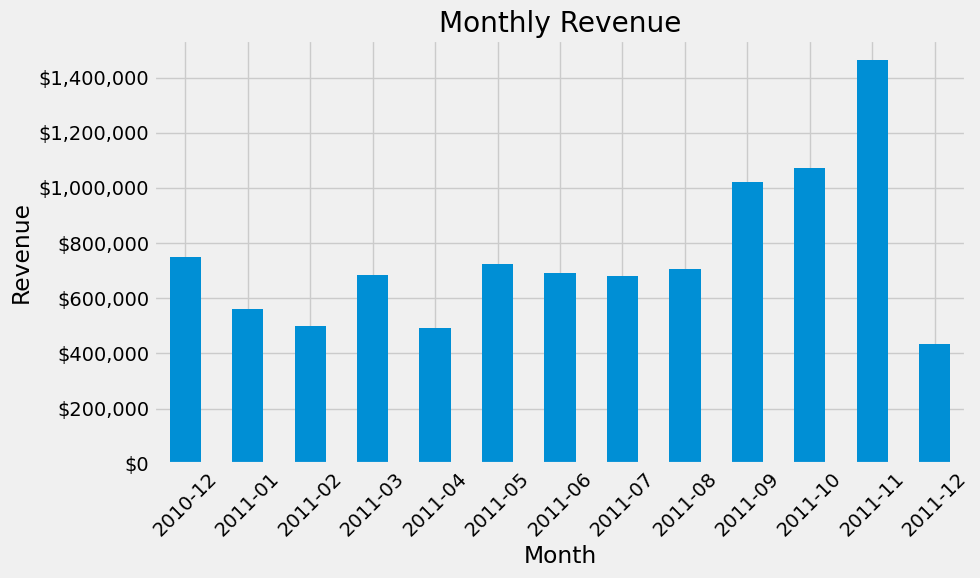

In [24]:
ax = monthly_revenue.plot(kind='bar', figsize=(10, 6))

import matplotlib.ticker as mticker
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.xticks(rotation=45);
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()

plt.savefig('images/monthly_revenue.png', dpi=300)

plt.show()

#### Insights:

- Revenue shows a clear upward trend throughout 2011.
- The highest revenue is observed in September, October, and November.
- The peak occurs in November, likely due to seasonal demand (pre-holiday period).
- December 2011 shows lower revenue, but this is due to incomplete data (only up to 9th December).
- Early months (January–February) have lower revenue, possibly due to post-holiday slowdown.

## How does revenue changes over days of week?

In [25]:
days_of_week_revenue = (
    data
    .groupby('day_of_week')['Revenue']
    .sum()
)

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']

days_of_week_revenue = days_of_week_revenue.loc[order]

days_of_week_revenue.round(2)

day_of_week
Monday       1588609.42
Tuesday      1966182.78
Wednesday     1734147.0
Thursday     2112518.99
Friday       1562734.92
Sunday        805678.89
Name: Revenue, dtype: Float64

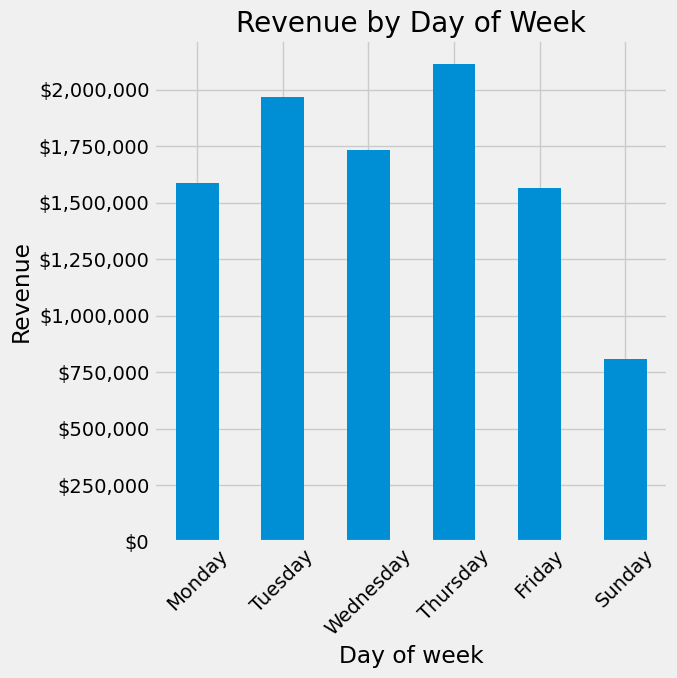

In [26]:
ax = days_of_week_revenue.plot.bar(figsize=(7, 7))

import matplotlib.ticker as mticker
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.xticks(rotation=45);

plt.title('Revenue by Day of Week')
plt.xlabel('Day of week')
plt.ylabel('Revenue')
plt.tight_layout()

plt.savefig('images/revenue_day_of_week.png', dpi=300)

plt.show()


#### Insights:

- Revenue is highest on Thursdays, indicating peak business activity.
- Weekdays (Tuesday–Thursday) generate the majority of revenue.
- No transactions are recorded on Saturdays, which may indicate that the business does not operate on this day. This is important to distinguish when interpreting daily trends.
- Sunday shows the lowest revenue, suggesting reduced customer activity.
- This pattern may indicate that most customers are businesses operating during weekdays.

## Sales by hour

#### Analyze how revenue is distributed throughout the day.

In [27]:
net_revenue_by_hour = (
    data
    .groupby(data['InvoiceDate'].dt.hour)['Revenue']
    .sum()
    .sort_index()
)

net_revenue_by_hour.round(2)

InvoiceDate
6        -497.35
7       31009.32
8      281840.86
9      766734.05
10    1329056.52
11    1147437.91
12    1362484.28
13    1177506.36
14    1117337.02
15    1189458.28
16     729140.82
17     435444.11
18     140574.48
19      46324.99
20      16020.37
Name: Revenue, dtype: Float64

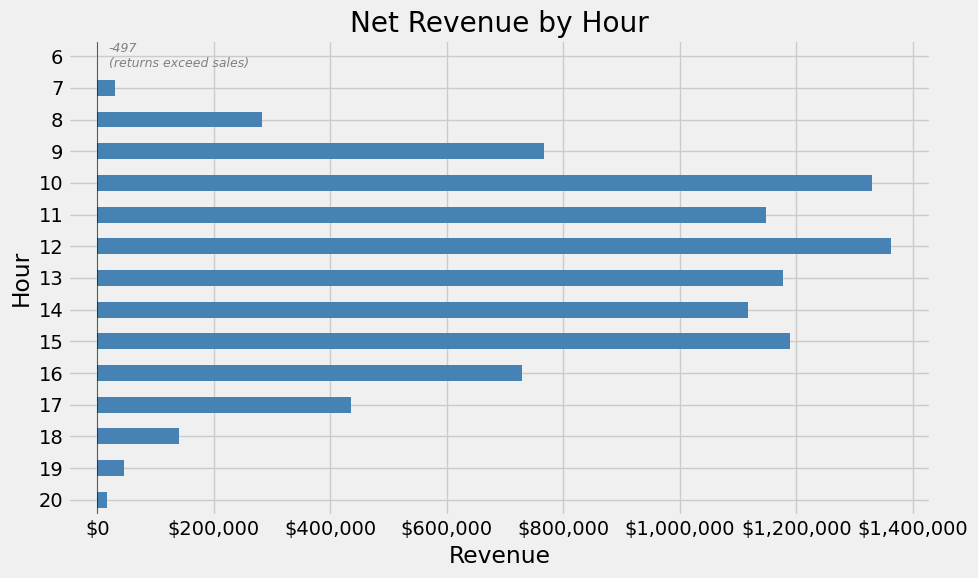

In [68]:

net_revenue_by_hour = net_revenue_by_hour.sort_index(ascending=False)
colors = ['red' if x < 0 else 'steelblue' for x in net_revenue_by_hour]
ax = net_revenue_by_hour.plot.barh(figsize=(10, 6), color=colors)

import matplotlib.ticker as mticker
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.axvline(0, color='black', linewidth=0.4)
ax.set_xlim(-50000, None)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for i, v in enumerate(net_revenue_by_hour):
    if v < 0:
        ax.text(v + 20000, i,
                f'{v:,.0f}\n(returns exceed sales)',
                va='center',
                color='grey',
                style='italic',
                fontsize=9)

plt.title('Net Revenue by Hour')
plt.xlabel('Revenue')
plt.ylabel('Hour')

plt.tight_layout()
plt.savefig('images/revenue_by_hour.png', dpi=300)
plt.show()


#### Insights:

- Revenue is concentrated during core business hours, with the highest contribution between 10 AM and 3 PM.
- Early morning hours show minimal or negative revenue, likely due to low sales activity and the processing of returns.
- Evening hours demonstrate a sharp decline in revenue, indicating reduced customer activity.
- Net revenue is slightly negative at 6 AM (~$500), which is negligible compared to overall revenue. This likely reflects returns being processed before sales activity begins.

## December seasonality

#### Since December is the only month that appears in both 2010 and 2011, we can compare revenue patterns across days to identify seasonal trends.

In [29]:
december = data[data['InvoiceDate'].dt.month == 12]

december['day'] = december['InvoiceDate'].dt.day

december['year'] = december['InvoiceDate'].dt.year

december


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,FreeFlag,Revenue,year_month,day_of_week,day,year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Sale,Paid,15.3,2010-12,Wednesday,1,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001,2010-12,Wednesday,1,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Sale,Paid,22.0,2010-12,Wednesday,1,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001,2010-12,Wednesday,1,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Paid,20.340001,2010-12,Wednesday,1,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,Sale,Paid,10.2,2011-12,Friday,9,2011
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.1,12680,France,Sale,Paid,12.599999,2011-12,Friday,9,2011
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,Sale,Paid,16.6,2011-12,Friday,9,2011
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,Sale,Paid,16.6,2011-12,Friday,9,2011


### Data Preparation
#### Aggregate daily revenue for each year

In [30]:
daily = (
    december
    .groupby(['year', 'day'])['Revenue']
    .sum()
    .reset_index()
)

daily.head()

,year,day,Revenue
0,2010,1,58635.559798
1,2010,2,46207.279748
2,2010,3,45620.459953
3,2010,5,31383.94977
4,2010,6,53860.179729


#### Reshape the data for comparison

In [31]:
pivot = daily.pivot(index='day', columns='year', values='Revenue')

pivot.head(11)

year,2010,2011
day,,
1,58635.559798,51410.949714
2,46207.279748,57086.059676
3,45620.459953,<NA>
4,<NA>,24565.779908
5,31383.94977,57751.318759
6,53860.179729,54228.369777
7,45059.049839,75076.219698
8,44189.839769,81417.780125
9,52532.129877,32131.529949


#### Note: December 2011 data is incomplete (only up to December 9), which limits full comparison

In [32]:
all_days = pd.Index(range(1, 11), name='day')
pivot = pivot.reindex(all_days)
pivot


year,2010,2011
day,,
1,58635.559798,51410.949714
2,46207.279748,57086.059676
3,45620.459953,<NA>
4,<NA>,24565.779908
5,31383.94977,57751.318759
6,53860.179729,54228.369777
7,45059.049839,75076.219698
8,44189.839769,81417.780125
9,52532.129877,32131.529949


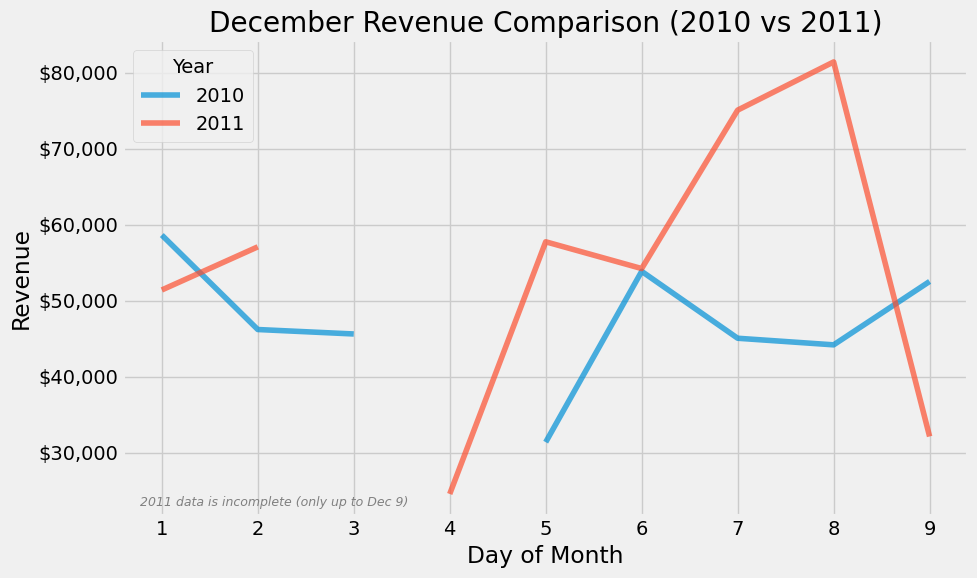

In [33]:
pivot.loc[1:9].plot(figsize=(10, 6), alpha=0.7)

plt.title('December Revenue Comparison (2010 vs 2011)');
plt.xlabel('Day of Month');
plt.ylabel('Revenue');
plt.legend(title='Year');
plt.xticks(range(1, 10));

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.annotate('2011 data is incomplete (only up to Dec 9)',
             xy=(0.02, 0.02), xycoords='axes fraction',
             fontsize=9, color='gray', style='italic')

plt.tight_layout()

plt.savefig('images/december_revenue_comparison.png', dpi=300)

plt.show()

#### Insights

- Comparison is limited to the first 9 days of December, as 2011 data is only available up to this point.
- Revenue patterns differ between the two years, suggesting variability in purchasing behavior.
- Certain days show no transactions, which corresponds to non-operating days on Saturday rather than zero revenue. 
- 2011 shows sharper peaks, indicating more concentrated purchasing activity.

## Top countries by revenue

In [34]:
country_revenue = (
    data
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

top_countries = country_revenue.round(2).head(10)
top_countries

Country
United Kingdom    8209930.44
Netherlands        284661.54
EIRE               263276.82
Germany            221698.21
France              197403.9
Australia          137077.27
Switzerland         56385.35
Spain               54774.58
Belgium             40910.96
Sweden              36595.91
Name: Revenue, dtype: Float64

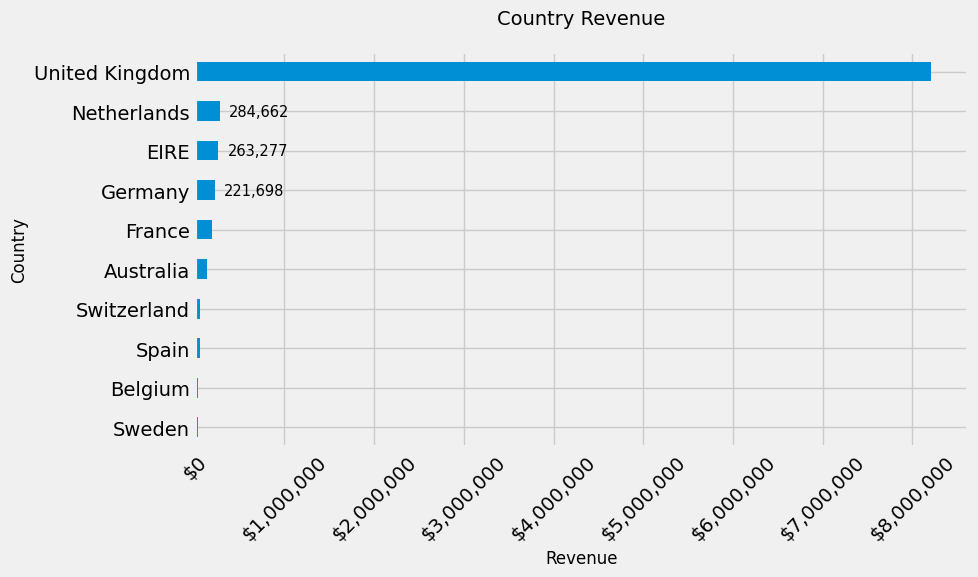

In [35]:
ax = top_countries.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6))

ax = top_countries.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(10, 6),
)

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45);
plt.title('Country Revenue', fontsize=14, pad=20)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Country', fontsize=12)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for i, v in enumerate(top_countries.sort_values(ascending=True)):
    if i in [6, 7, 8]:
        ax.text(
            v + 100000,
            i,
            f'{v:,.0f}',
            va='center',
            ha='left',
            fontsize=10.5,
        )

plt.tight_layout()
plt.savefig('images/top_country_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
uk_share = country_revenue['United Kingdom'] / country_revenue.sum() * 100
print(f"UK shares: {uk_share:,.2f}%")

UK shares: 84.03%


#### Insight
The United Kingdom dominates revenue, accounting for ~84% of total revenue.

However, the presence of international revenue (~16%) indicates that the business has a global customer base despite being UK-based, likely driven by online sales and wholesale distribution.

The United Kingdom dominates revenue, accounting for the vast majority of sales.

To better understand the contribution of other countries, the UK was excluded from the comparison chart.

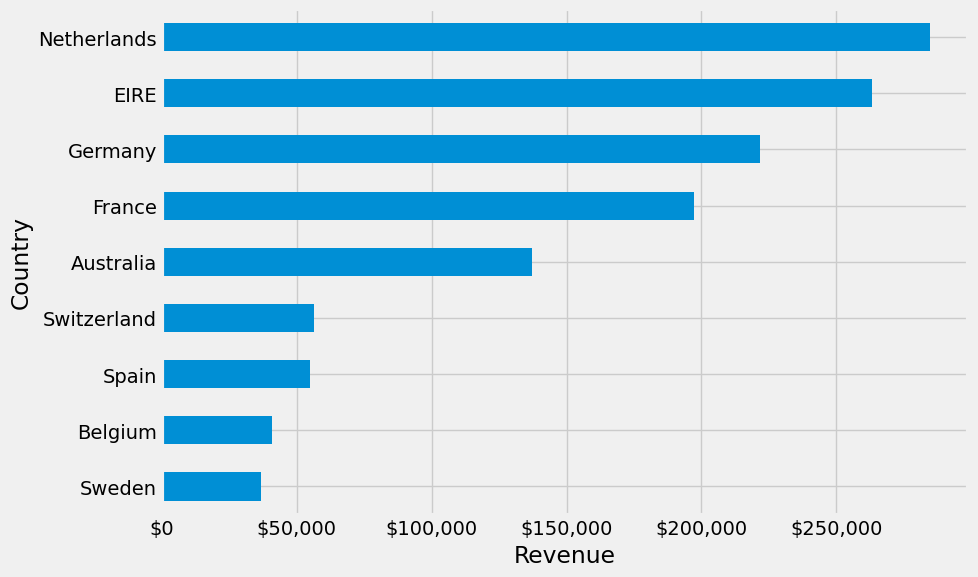

In [37]:
top_countries_no_uk = top_countries.drop('United Kingdom').sort_values(ascending=True)
top_countries_no_uk.plot(kind='barh', figsize=(10, 6), xlabel='Revenue');

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()

plt.savefig('images/top_countries_no_uk.png', dpi=300)

plt.show()

#### Insights:

- Among non-UK countries, the Netherlands, EIRE, and Germany generate the highest revenue.
- The remaining countries contribute significantly less, indicating the precense of international sales.
- Overall, non-UK countries account for only a small share of total revenue (~16%), highlighting the company’s heavy reliance on the domestic market.

In [38]:
top_country_quantity = (
    data
    .groupby('Country')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

top_country_quantity.round(2).head(10)


Country
United Kingdom    4263827
Netherlands        200128
EIRE               142637
Germany            117448
France             110480
Australia           83653
Sweden              35637
Switzerland         30325
Spain               26824
Japan               25218
Name: Quantity, dtype: Int32

#### Insigt
Top countries by quantity largely mirror revenue distribution, indicating that high-revenue countries also have high sales volume.

## Top Products by revenue

In [39]:
product_revenue = (
    data
    .groupby(['StockCode', 'Description'])['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

product_revenue = product_revenue.round(2).head(15)
product_revenue

StockCode  Description                       
DOT        DOTCOM POSTAGE                        206245.48
22423      REGENCY CAKESTAND 3 TIER              164762.19
47566      PARTY BUNTING                          98302.98
85123A     WHITE HANGING HEART T-LIGHT HOLDER     97715.99
85099B     JUMBO BAG RED RETROSPOT                92356.03
23084      RABBIT NIGHT LIGHT                     66756.59
POST       POSTAGE                                66230.64
22086      PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
84879      ASSORTED COLOUR BIRD ORNAMENT          58959.73
79321      CHILLI LIGHTS                          53768.06
23298      SPOTTY BUNTING                         42065.32
22386      JUMBO BAG PINK POLKADOT                41619.66
21137      BLACK RECORD COVER FRAME               40596.96
22502      PICNIC BASKET WICKER 60 PIECES          39619.5
22720      SET OF 3 CAKE TINS PANTRY DESIGN       37413.44
Name: Revenue, dtype: Float64

Shipping-related entries such as "POSTAGE" and "DOTCOM POSTAGE" appear among the top revenue-generating items.

However, these are not actual products but represent delivery charges.

These entries are excluded from product-level analysis to focus only on actual merchandise.

In [40]:
clean_data = data[~data['Description'].str.contains('POSTAGE', case=False, na=False)]

product_revenue = (
    clean_data
    .groupby(['StockCode', 'Description'])['Revenue']
    .sum()

    .sort_values(ascending=False)
    .head(15)
)

product_revenue = product_revenue.round(2).head(15)
product_revenue


StockCode  Description                       
22423      REGENCY CAKESTAND 3 TIER              164762.19
47566      PARTY BUNTING                          98302.98
85123A     WHITE HANGING HEART T-LIGHT HOLDER     97715.99
85099B     JUMBO BAG RED RETROSPOT                92356.03
23084      RABBIT NIGHT LIGHT                     66756.59
22086      PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
84879      ASSORTED COLOUR BIRD ORNAMENT          58959.73
79321      CHILLI LIGHTS                          53768.06
23298      SPOTTY BUNTING                         42065.32
22386      JUMBO BAG PINK POLKADOT                41619.66
21137      BLACK RECORD COVER FRAME               40596.96
22502      PICNIC BASKET WICKER 60 PIECES          39619.5
22720      SET OF 3 CAKE TINS PANTRY DESIGN       37413.44
23284      DOORMAT KEEP CALM AND COME IN          36565.39
22960      JAM MAKING SET WITH JARS               36116.09
Name: Revenue, dtype: Float64

Top-performing items now reflect true merchandise rather than operational charges.

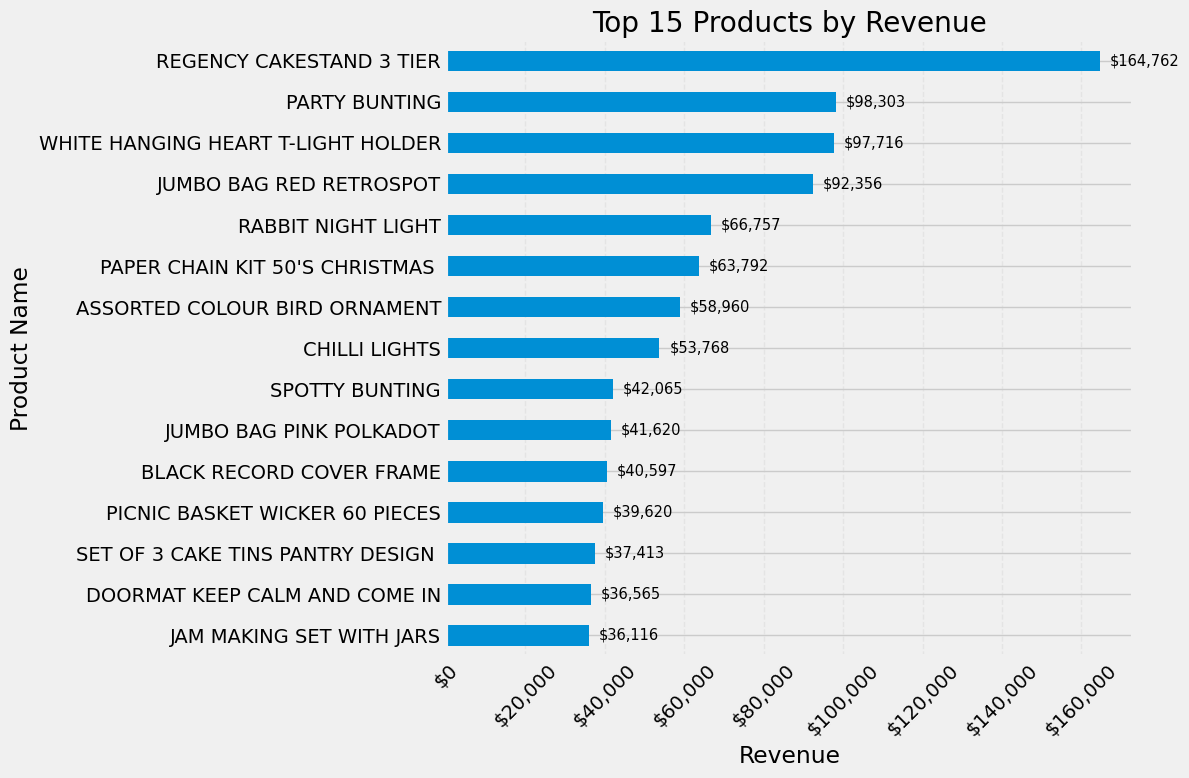

In [41]:

product_revenue.index = product_revenue.index.get_level_values('Description')

ax = product_revenue.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(12, 8)
)

plt.xticks(rotation=45);

plt.title('Top 15 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Name')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

offset = max(product_revenue) * 0.015

for i, v in enumerate(product_revenue.sort_values(ascending=True)):
    ax.text(v + offset, i, f'${v:,.0f}',
            va='center',
            fontsize=10.5,
            fontweight='medium')

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()

plt.savefig('images/top_product_revenue.png', dpi=300)

plt.show()

#### Insights:

- One product (REGENCY CAKESTAND 3 TIER ) clearly leads in revenue, while the rest of the top products show a relatively even distribution with gradual decline rather than strong concentration.

- Apart from the leading product, revenue differences between other top items are relatively moderate, indicating a balanced product portfolio.

- Many top-performing products are decorative or gift-oriented, though functional items such as bags and kitchen-related products also contribute significantly to revenue.

- Beyond the top 5 products, revenue levels become more uniform, forming a long tail of mid-performing items.

- Some product categories (e.g., bags and decorative items like bunting) appear multiple times among top performers, indicating pockets of consistent demand rather than a single dominant category.

In [69]:
clean_data[clean_data['FreeFlag'] == 'Free']['Description'].value_counts().head(10)

Description
Unknown                          1454
check                             159
?                                  47
damages                            45
damaged                            43
found                              25
sold as set on dotcom              20
adjustment                         16
Damaged                            14
FRENCH BLUE METAL DOOR SIGN 1       9
Name: count, dtype: int64

##### A subset of transactions with zero unit price (labeled as "Free") contains entries such as “Unknown”, “check”, “damaged”, and “adjustment”. 
##### These descriptions indicate that such records do not correspond to actual products or customer purchases. Instead, they represent internal operations, including stock corrections, quality issues, or accounting adjustments.

In [43]:
products_free = (
    data[data['Description'].str.contains('sample|given|free', case=False, na=False)]
    .groupby('Description')['Revenue']
    .sum()
    .abs()
    .sort_values()
)

products_free = products_free.round(2)
products_free.head(10)

Description
Damages/samples                     0.0
Given away                          0.0
samples                             0.0
Show Samples                        0.0
samples/damages                     0.0
FREESTYLE CANVAS ART PICTURE      39.65
SAMPLES                         3049.39
Name: Revenue, dtype: Float64

##### A small subset of zero-revenue transactions includes descriptions such as “Given away” and “samples”, which may suggest non-commercial distribution of goods. However, these entries are sparse and inconsistent, and the dataset lacks clear indicators of structured promotional activity (e.g., “free gift”, “promotion”, or discount-based labels).

##### Therefore, free transactions in this dataset are not promotional giveaways but operational entries, and should be treated separately in the analysis.

## Top Products by quantity

In [70]:
product_quantity = (
    clean_data
    .groupby(['StockCode', 'Description'])['Quantity']
    .sum()
    .sort_values(ascending=False)
)

product_quantity = product_quantity.round(2).head(15)
product_quantity

StockCode  Description                       
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
85099B     JUMBO BAG RED RETROSPOT               47363
84879      ASSORTED COLOUR BIRD ORNAMENT         36381
22197      POPCORN HOLDER                        36334
21212      PACK OF 72 RETROSPOT CAKE CASES       36039
85123A     WHITE HANGING HEART T-LIGHT HOLDER    35025
23084      RABBIT NIGHT LIGHT                    30680
22492      MINI PAINT SET VINTAGE                26437
22616      PACK OF 12 LONDON TISSUES             26315
21977      PACK OF 60 PINK PAISLEY CAKE CASES    24753
22178      VICTORIAN GLASS HANGING T-LIGHT       23854
15036      ASSORTED COLOURS SILK FAN             23082
17003      BROCADE RING PURSE                    23053
21915      RED  HARMONICA IN BOX                 21866
22386      JUMBO BAG PINK POLKADOT               21009
Name: Quantity, dtype: Int32

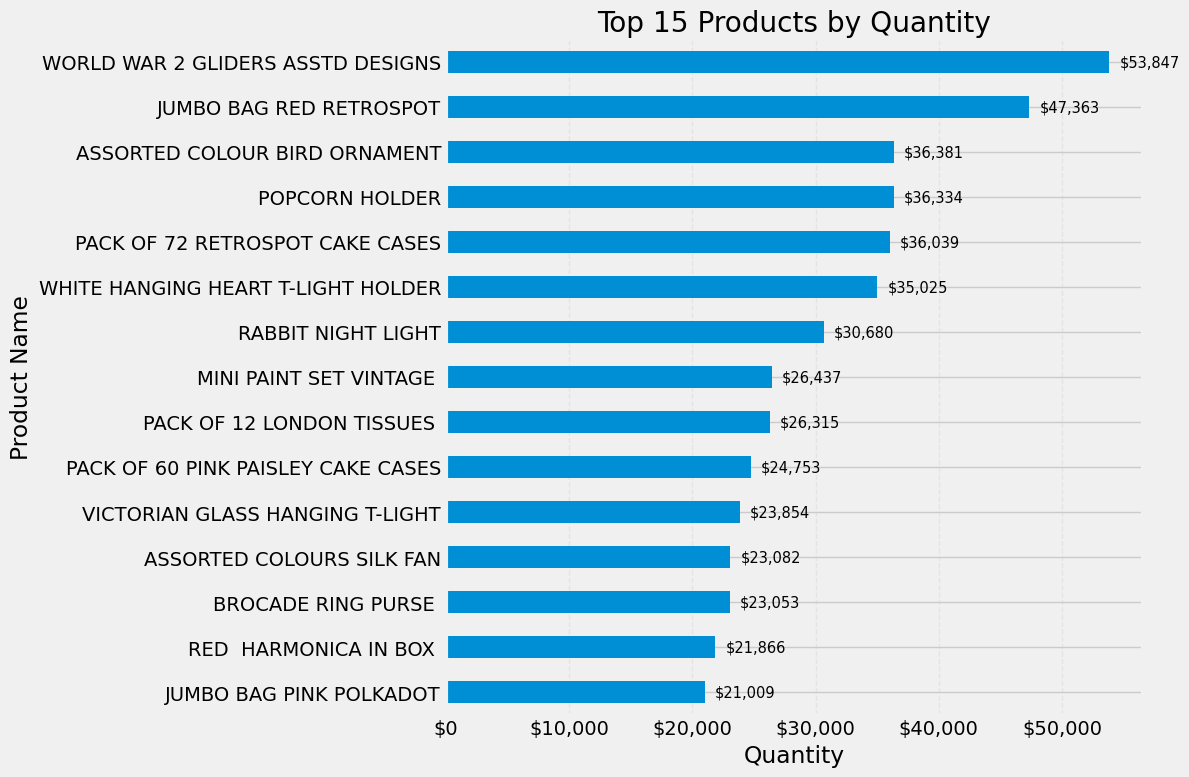

In [45]:
product_quantity.index = product_quantity.index.get_level_values('Description')

plt.figure(figsize=(12, 8))

ax = product_quantity.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(12, 8)
)

plt.title('Top 15 Products by Quantity')
plt.xlabel('Quantity')
plt.ylabel('Product Name')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

offset = max(product_quantity) * 0.015

for i, v in enumerate(product_quantity.sort_values(ascending=True)):
    ax.text(v + offset, i, f'${v:,.0f}',
            va='center',
            fontsize=10.5,
            fontweight='medium')

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()

plt.savefig('images/top_product_quantity.png', dpi=300)

plt.show()

#### Insights:

- The top-selling products by quantity differ significantly from top revenue-generating products, indicating varying price levels across items.

- Some products achieve high quantity volumes but contribute less to revenue, suggesting they are lower-priced, high-frequency purchases.

- High-revenue products are not necessarily the most frequently purchased, implying a mix of premium and mass-market items.

#### Identification of overlapping top-performing products across revenue and quantity metrics

In [46]:
top_rev = set(product_revenue.index)
top_qty = set(product_quantity.index)

intersection = top_rev.intersection(top_qty)
intersection

{'ASSORTED COLOUR BIRD ORNAMENT',
 'JUMBO BAG PINK POLKADOT',
 'JUMBO BAG RED RETROSPOT',
 'RABBIT NIGHT LIGHT',
 'WHITE HANGING HEART T-LIGHT HOLDER'}

#### To better understand product performance, we combine revenue and quantity into a single dataset at the product level.

In [47]:
product_stats = (
    clean_data
    .groupby(['StockCode', 'Description'])
    .agg({
        'Quantity': 'sum',
        'Revenue': 'sum'
    })
    .reset_index()
)

product_stats

,StockCode,Description,Quantity,Revenue
0,10002,INFLATABLE POLITICAL GLOBE,860,759.890019
1,10002,Unknown,177,0.0
2,10080,GROOVY CACTUS INFLATABLE,303,119.089996
3,10080,check,22,0.0
4,10080,Unknown,170,0.0
...,...,...,...,...
5745,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,7,175.530001
5746,gift_0001_30,Unknown,30,0.0
5747,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,3,100.700005
5748,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,4,167.559994


#### To explain differences between high-revenue and high-volume products, we calculate the average price per product.

In [48]:
product_stats['AvgPrice'] = product_stats['Revenue'] / product_stats['Quantity']
product_stats

,StockCode,Description,Quantity,Revenue,AvgPrice
0,10002,INFLATABLE POLITICAL GLOBE,860,759.890019,0.883593
1,10002,Unknown,177,0.0,0.0
2,10080,GROOVY CACTUS INFLATABLE,303,119.089996,0.393036
3,10080,check,22,0.0,0.0
4,10080,Unknown,170,0.0,0.0
...,...,...,...,...,...
5745,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,7,175.530001,25.075714
5746,gift_0001_30,Unknown,30,0.0,0.0
5747,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,3,100.700005,33.566668
5748,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,4,167.559994,41.889998


#### We examine the distribution of average prices to identify potential outliers and understand pricing variability across products.

In [49]:
top_products = product_stats.sort_values(by='Revenue', ascending=False).head(100)
top_products['AvgPrice'].describe()

count        100.0
mean      12.72047
std      69.338873
min       0.584359
25%       1.927799
50%       2.879072
75%       5.073909
max          649.5
Name: AvgPrice, dtype: Float64

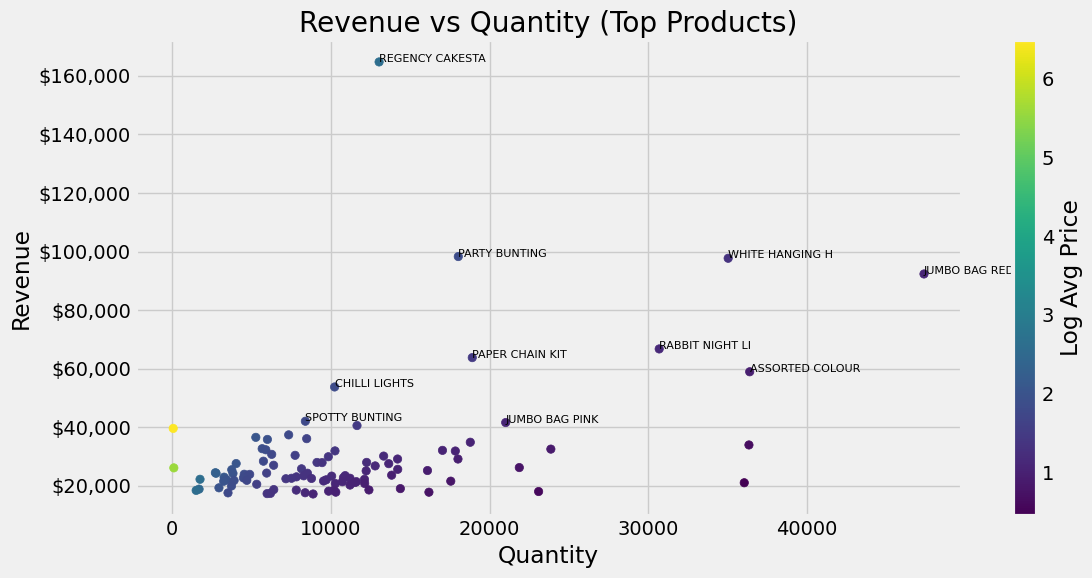

In [72]:
import numpy as np

plt.figure(figsize=(12, 6))

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))


plt.scatter(
    top_products['Quantity'],
    top_products['Revenue'],
    c=np.log1p(top_products['AvgPrice'])  # ось тут магія
)
plt.colorbar(label='Log Avg Price')

top_10 = top_products.head(10)

for _, row in top_10.iterrows():
    plt.text(
        row['Quantity'],
        row['Revenue'],
        row['Description'][:15],
        fontsize=8
    )

plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.title('Revenue vs Quantity (Top Products)')

plt.tight_layout()

plt.savefig('images/top_products_revenue_vs_quantity.png', dpi=300)

plt.show()

#### Insights:

- High-volume products tend to have lower average prices, while high-revenue products are often driven by higher unit prices rather than volume.
- Revenue leaders are not necessarily volume leaders, indicating different product strategies (premium vs mass-market).
- A small number of products achieve both high sales volume and high revenue, representing key drivers of overall performance.
- A large number of products contribute relatively little to both revenue and sales volume, forming a long tail.

In [51]:
top_rev_product = product_stats.sort_values(by='Revenue', ascending=False).iloc[0]

top_rev_product[['Description', 'Revenue', 'Quantity', 'AvgPrice']]

Description    REGENCY CAKESTAND 3 TIER
Revenue                    164762.18779
Quantity                          13033
AvgPrice                      12.641923
Name: 1931, dtype: object

In [52]:
top_qty_product = product_stats.sort_values(by='Quantity', ascending=False).iloc[0]

top_qty_product[['Description', 'Revenue', 'Quantity', 'AvgPrice']]

Description    WORLD WAR 2 GLIDERS ASSTD DESIGNS
Revenue                             13587.929637
Quantity                                   53847
AvgPrice                                0.252343
Name: 4283, dtype: object

##### The top revenue-generating product (REGENCY CAKESTAND 3 TIER) has an average price of ~$12.6, while the top-selling product by quantity (WORLD WAR 2 GLIDERS ASSTD DESIGNS) is priced at only ~$0.25. Despite being sold in over 4 times higher volume, the latter generates significantly less revenue, highlighting a clear distinction between premium and low-cost, high-volume products.

## Top Customers by revenue

In [53]:
clean_data['CustomerID'].nunique()

4372

##### The dataset contains 4,372 unique customers, indicating a broad customer base.

##### Customer-level revenue was calculated to identify top-performing customers.

In [54]:
customer_revenue = (
    clean_data
    .groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

customer_revenue = customer_revenue.round(2)
customer_revenue.head(15)

CustomerID
14646    278466.02
18102    256438.49
17450    188420.57
14911    132572.62
12415    123638.18
14156    113384.14
17511     88127.55
16684     65892.08
13694      62653.1
15311     59419.34
13089     57385.88
15061     54228.74
17949     52750.84
15769     51823.72
16029     50992.61
Name: Revenue, dtype: Float64

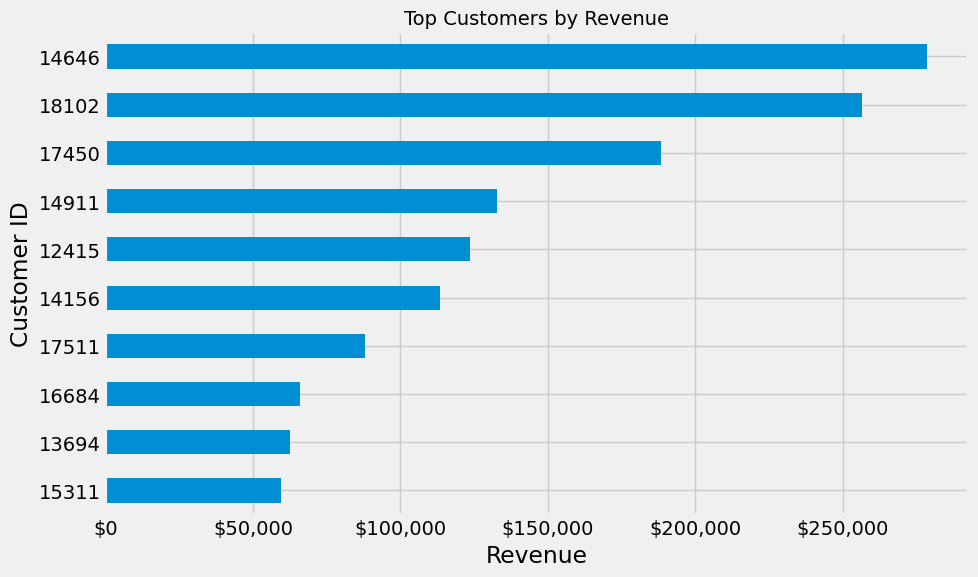

In [55]:
customer_revenue = customer_revenue.head(10).sort_values(ascending=True)
customer_revenue.plot(kind='barh', figsize=(10, 6), xlabel='Revenue');

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.title('Top Customers by Revenue', fontsize=14)
plt.ylabel('Customer ID')

plt.tight_layout()

plt.savefig('images/top_customers_revenue.png', dpi=300)

plt.show()

#### Insights:
- Revenue distribution among top customers is relatively balanced. While Customer 14646 generates the highest revenue, the gap between top customers is not extreme. This indicates that the business is not overly dependent on a single client.
- A small group of top customers contributes more revenue, followed by a gradual decline across others, but without strong concentration.

##### To analyze customer behavior, total revenue and the number of unique orders were aggregated at the customer level. This allowed for the calculation of average order value (AOV), providing insight into whether customers generate revenue through frequent purchases or higher-value transactions.

In [56]:
customer_stats = (
    clean_data
    .groupby('CustomerID')
    .agg({
        'Country': 'first',
        'Revenue': 'sum',
        'InvoiceNo': 'nunique'
    })
    .rename(columns={'InvoiceNo': 'Orders'})
)

customer_stats['AvgOrderValue'] = customer_stats['Revenue'] / customer_stats['Orders']

top_customers = customer_stats.sort_values(by='AvgOrderValue', ascending=False).head(20)
top_customers

,Country,Revenue,Orders,AvgOrderValue
CustomerID,,,,
12357,Switzerland,6207.669989,1,6207.669989
15749,United Kingdom,21535.899814,4,5383.974953
12415,Australia,123638.180134,24,5151.590839
12688,Israel,4873.809998,1,4873.809998
12590,Germany,9338.379929,2,4669.189965
12752,Norway,4366.780012,1,4366.780012
18251,United Kingdom,4314.719962,1,4314.719962
18102,United Kingdom,256438.488361,62,4136.104651
16000,United Kingdom,12393.699977,3,4131.233326


##### Interestingly, several high-value customers are located outside the United Kingdom, suggesting that international customers may place fewer but significantly larger orders.

#### Each order (InvoiceNo) may include multiple products, meaning that a single order can consist of several line items. Therefore, average order value may reflect the total value of all items within an order rather than a single product purchase.

In [57]:
customer_12357 = clean_data[clean_data['CustomerID'] == 14646]
customer_12357

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,FreeFlag,Revenue,year_month,day_of_week
37952,539491,21981,PACK OF 12 WOODLAND TISSUES,12,2010-12-20 10:09:00,0.29,14646,Netherlands,Sale,Paid,3.48,2010-12,Monday
37953,539491,21986,PACK OF 12 PINK POLKADOT TISSUES,12,2010-12-20 10:09:00,0.29,14646,Netherlands,Sale,Paid,3.48,2010-12,Monday
37954,539491,22720,SET OF 3 CAKE TINS PANTRY DESIGN,2,2010-12-20 10:09:00,4.95,14646,Netherlands,Sale,Paid,9.9,2010-12,Monday
37955,539491,21931,JUMBO STORAGE BAG SUKI,1,2010-12-20 10:09:00,1.95,14646,Netherlands,Sale,Paid,1.95,2010-12,Monday
37956,539491,22613,PACK OF 20 SPACEBOY NAPKINS,2,2010-12-20 10:09:00,0.85,14646,Netherlands,Sale,Paid,1.7,2010-12,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
534958,581176,22908,PACK OF 20 NAPKINS RED APPLES,96,2011-12-07 15:19:00,0.72,14646,Netherlands,Sale,Paid,69.120003,2011-12,Wednesday
534959,581176,22907,PACK OF 20 NAPKINS PANTRY DESIGN,96,2011-12-07 15:19:00,0.72,14646,Netherlands,Sale,Paid,69.120003,2011-12,Wednesday
534960,581176,22029,SPACEBOY BIRTHDAY CARD,72,2011-12-07 15:19:00,0.36,14646,Netherlands,Sale,Paid,25.920001,2011-12,Wednesday
534961,581176,22712,CARD DOLLY GIRL,72,2011-12-07 15:19:00,0.36,14646,Netherlands,Sale,Paid,25.920001,2011-12,Wednesday


##### This visualization helps segment customers by behavior: high-frequency vs high-value customers.

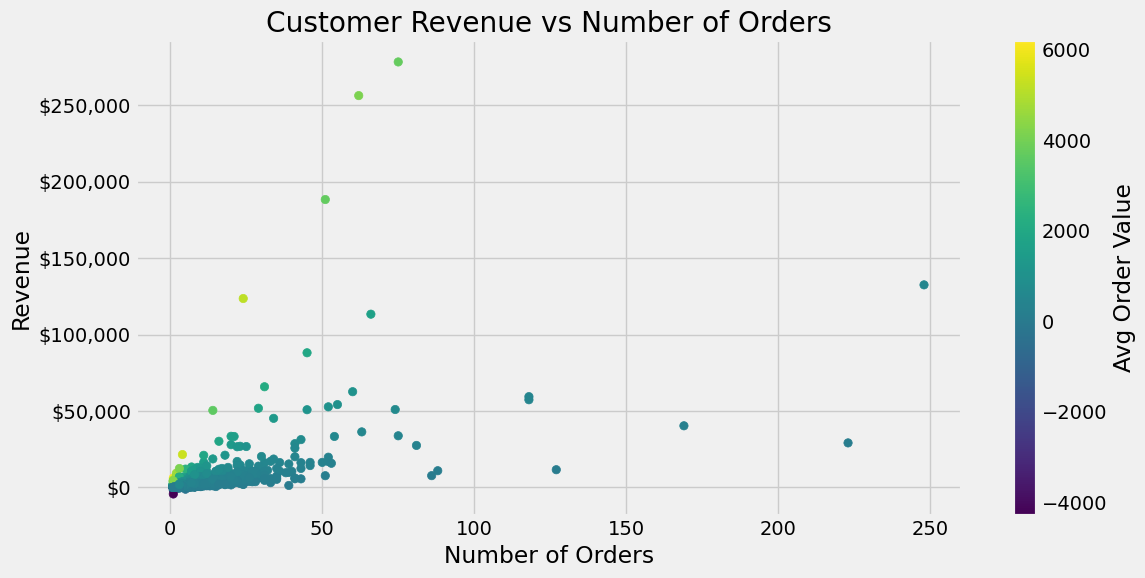

In [74]:
plt.figure(figsize=(12, 6))

plt.scatter(
    customer_stats['Orders'],
    customer_stats['Revenue'],
    c=customer_stats['AvgOrderValue'],
    cmap='viridis'
)

plt.colorbar(label='Avg Order Value')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xlabel('Number of Orders')
plt.ylabel('Revenue')
plt.title('Customer Revenue vs Number of Orders')

plt.tight_layout()

plt.savefig('images/customer_revenue_vs_number_of_orders.png', dpi=300)

plt.show()

#### Insight:
The scatter plot shows that customer revenue is not solely driven by purchase frequency. While some customers generate high revenue through frequent orders, others achieve comparable revenue through a small number of high-value purchases.

This highlights two distinct customer behaviors:
- frequent, lower-value purchasing
- infrequent, high-value (bulk) purchasing

Additionally, most customers are concentrated in the lower revenue range, indicating a long-tail distribution where a small number of customers contribute disproportionately to total revenue.

Some customers show negative revenue and average order value, reflecting cases where returns exceed purchases. These cases are included to preserve data integrity and are explored further in the returns analysis section.

## Returns Analysis

Total returns amounted to **$896,812.48**, representing a significant reduction in overall revenue ($10,666,684.49).

This highlights the importance of understanding return patterns and their impact on business performance.

In [59]:
return_rate = total_returns / total_sales
return_rate

0.08407602963680919

Returns account for approximately **~8.4%** of total sales revenue, indicating a moderate level of product returns that has a noticeable impact on overall business performance.

This suggests that while the majority of sales are retained, returns still represent a meaningful revenue loss.

🧾 Handling Zero-Value Returns

Initial analysis of returns revealed a large number of transactions with zero revenue. 
Investigation showed that these entries are associated with:

- zero unit prices,
- missing customer IDs,
- unusually large negative quantities,
- descriptions such as "samples", "missing", and "Given away".

These characteristics indicate internal or operational records (e.g., inventory adjustments or stock corrections), rather than actual customer returns.

To focus on financially meaningful returns, only transactions with negative revenue 

In [75]:
returns_clean = clean_data[(clean_data['Revenue'] < 0) ]

products_top_return = (
    returns_clean[returns_clean['TransactionType'] == 'Return']
    .groupby('Description')['Revenue']
    .sum()
    .abs()
    .sort_values()
)

products_top_return = products_top_return.round(2)
products_top_return.head(10)

Description
HANGING WOOD AND FELT FLOWER          0.12
STARS GIFT TAPE                       0.19
RECYCLED PENCIL WITH RABBIT ERASER    0.21
FRENCH STYLE STORAGE JAR JAM          0.29
STRIPY DESIGN SHOWER CAP              0.29
MAGNETS PACK OF 4 HOME SWEET HOME     0.39
BLACK SMALL GLASS CAKE STAND          0.39
PACK OF 12 SUKI TISSUES               0.39
TUMBLER BAROQUE                       0.39
WAKE UP COCKEREL TILE HOOK            0.39
Name: Revenue, dtype: Float64

In [61]:
clean_data[(clean_data['Description'] == 'HANGING WOOD AND FELT FLOWER') &
    (clean_data['TransactionType'] == 'Return')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,FreeFlag,Revenue,year_month,day_of_week
504697,C578991,85204,HANGING WOOD AND FELT FLOWER,-1,2011-11-27 15:31:00,0.12,15555,United Kingdom,Return,Paid,-0.12,2011-11,Sunday


In [62]:
products_top_return.sum()

884937.9500000001

In [63]:
total_returns.sum()

896812.4810653627

##### During the return analysis, a small discrepancy was observed between total returns and the aggregated returns by product.

##### Further investigation revealed that this difference is caused by service-related entries such as "POSTAGE" and "DOTCOM POSTAGE".

##### Although these entries are not actual products and were excluded from the product-level analysis, they do include return transactions (e.g., refunded shipping costs).

##### As a result, total return values calculated on the full dataset are slightly higher than those based on the cleaned dataset used for product analysis.

##### This difference (~$11.9K) is therefore expected and reflects the exclusion of non-product items from the analysis.

In [64]:
products_top_return.sort_values(ascending=False).head(20)

Description
AMAZON FEE                            235281.59
PAPER CRAFT , LITTLE BIRDIE           168469.59
Manual                                146784.46
MEDIUM CERAMIC TOP STORAGE JAR         77479.64
REGENCY CAKESTAND 3 TIER                9722.55
CRUK Commission                         7933.43
Bank Charges                            7340.64
WHITE HANGING HEART T-LIGHT HOLDER       6624.3
FAIRY CAKE FLANNEL ASSORTED COLOUR      6591.42
Discount                                5696.22
PANTRY CHOPPING BOARD                   4803.06
DOORMAT FAIRY CAKE                       4554.9
GIN + TONIC DIET METAL SIGN             3775.33
TEA TIME PARTY BUNTING                  3692.95
FELTCRAFT DOLL MOLLY                    3512.65
COLOUR GLASS. STAR T-LIGHT HOLDER       3246.16
SAMPLES                                 3112.44
PINK BLUE FELT CRAFT TRINKET BOX        2778.77
IVORY DINER WALL CLOCK                   2653.7
RED RETROSPOT CAKE STAND                 2480.5
Name: Revenue, dtype: Float6

##### Some of the highest return values are associated with non-product entries such as fees, commissions, and manual adjustments. These reflect financial corrections rather than physical product returns.

In [65]:
exclude_keywords = ['FEE', 'CHARGE', 'DISCOUNT', 'MANUAL', 'COMMISSION', 'SAMPLE']

products_only = returns_clean[
    ~returns_clean['Description'].str.contains('|'.join(exclude_keywords), case=False, na=False)
]

products_top_return = (
    products_only
    .groupby('Description')['Revenue']
    .sum()
    .abs()
    .sort_values(ascending=False)
)

products_top_return.sort_values(ascending=False).head(20)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.593821
MEDIUM CERAMIC TOP STORAGE JAR         77479.637159
REGENCY CAKESTAND 3 TIER                9722.549872
WHITE HANGING HEART T-LIGHT HOLDER      6624.299889
FAIRY CAKE FLANNEL ASSORTED COLOUR      6591.419702
PANTRY CHOPPING BOARD                   4803.059974
DOORMAT FAIRY CAKE                           4554.9
GIN + TONIC DIET METAL SIGN             3775.330046
TEA TIME PARTY BUNTING                   3692.94994
FELTCRAFT DOLL MOLLY                    3512.649932
COLOUR GLASS. STAR T-LIGHT HOLDER           3246.16
PINK BLUE FELT CRAFT TRINKET BOX        2778.769852
IVORY DINER WALL CLOCK                   2653.70003
RED RETROSPOT CAKE STAND                2480.499964
JUMBO BAG RED RETROSPOT                 1984.019973
FLOWERS CHANDELIER T-LIGHT HOLDER       1859.069962
VINTAGE RED KITCHEN CABINET                  1730.5
ROUND SNACK BOXES SET OF 4 FRUITS       1691.499972
HOT WATER BOTTLE I AM SO POORLY              1679.7


##### The analysis was further refined by excluding non-product entries (e.g., fees, discounts, commissions and samples) to focus on actual merchandise returns.

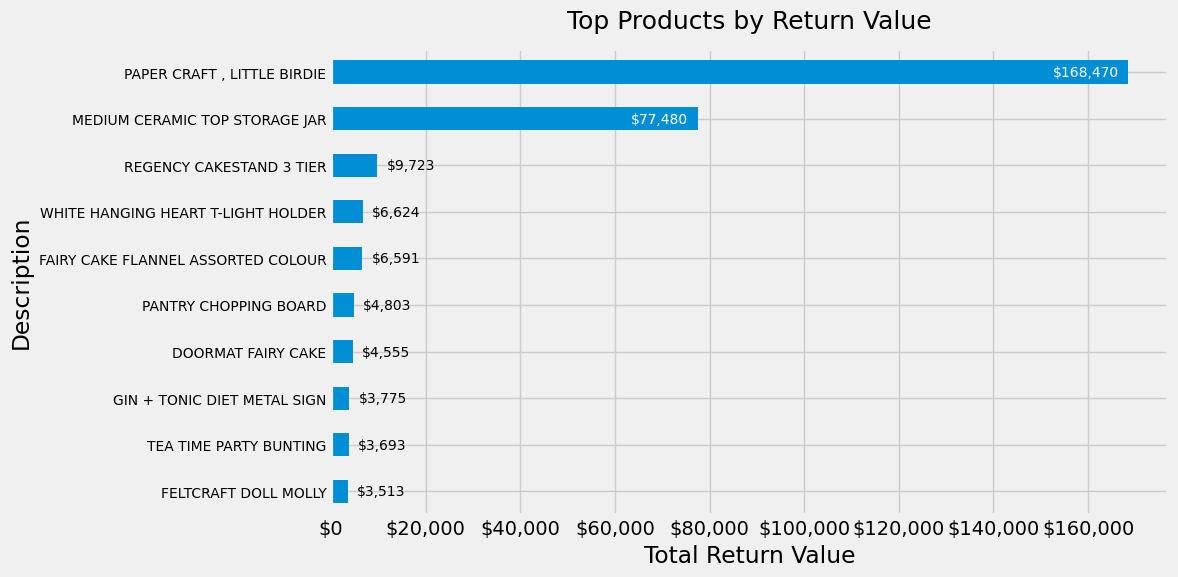

In [66]:
plt.figure(figsize=(12, 6))

ax = products_top_return.head(10).sort_values().plot(
    kind='barh',
    xlabel='Total Return Value'
)

plt.title('Top Products by Return Value', fontsize=18, pad=15)

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

data = products_top_return.head(10).sort_values()

offset = 2000

for i, v in enumerate(data):
    if v > 20000:
        ax.text(v - offset, i, f'${v:,.0f}',
                va='center', ha='right', color='white', fontsize=10)
    else:
        ax.text(v + offset, i, f'${v:,.0f}',
                va='center', ha='left', color='black', fontsize=10)

plt.yticks(fontsize=10);

plt.tight_layout()

plt.savefig('images/top_products_by_return.png', dpi=300)

plt.show()

### **Insights**:

#### The distribution of return value is skewed.

#### A small number of products contribute disproportionately to total return value, with "Paper Craft, Little Birdie" significantly exceeding all other items.

#### This suggests that return issues are not widespread across the catalog, but are instead concentrated in specific products.

#### **Such patterns may indicate**:

#### • Product quality issues  
#### • Packaging problems  
#### • Mismatches between customer expectations and actual product characteristics  

#### Further investigation into these specific items is recommended.

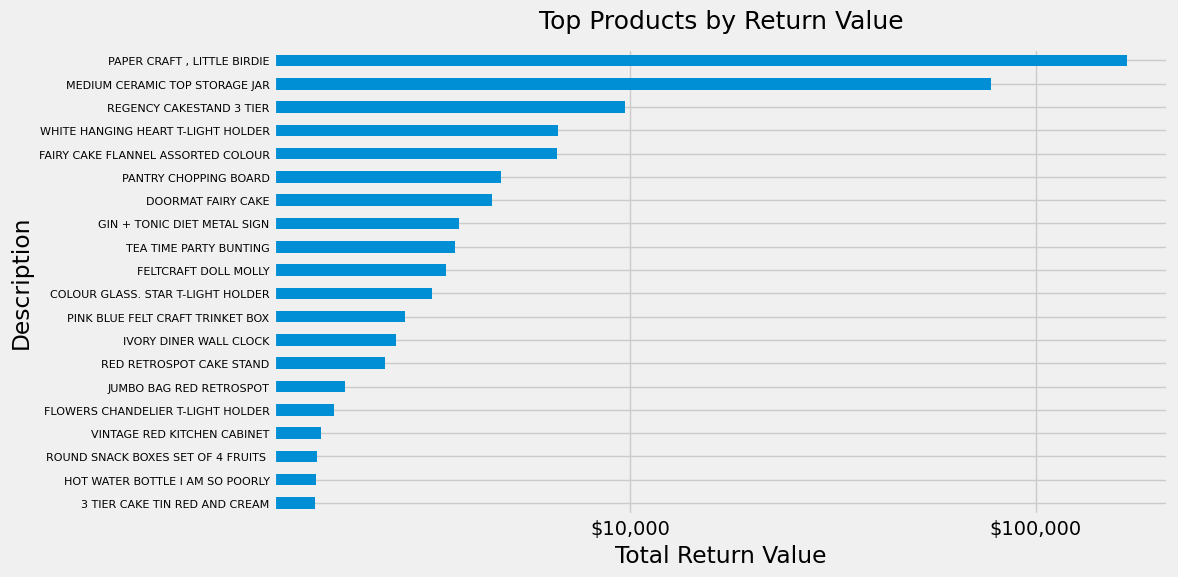

In [67]:
plt.figure(figsize=(12, 6))

products_top_return.head(20).sort_values().plot(kind='barh', xlabel='Total Return Value')

plt.xscale('log')

plt.title('Top Products by Return Value', fontsize=18, pad=15)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.yticks(fontsize=8);

plt.tight_layout()

plt.savefig('images/top_20_products_by_return.png', dpi=300)

plt.show()

### 📊 Log-Scale View for Better Distribution Analysis

Due to the extreme skew in return values, a logarithmic scale was applied to better visualize differences among lower-ranked products.

While the top 2 products dominate in absolute terms, the log-scale chart reveals a more gradual decline across the remaining items.

This confirms that beyond the major outliers, return values are relatively evenly distributed without sharp drops, indicating no additional extreme anomalies in the rest of the product set.

### 📊 Returns vs Product Performance

To better understand return behavior, top returned products were compared with top-performing items by revenue and quantity.

Only a small subset of products appears in both groups, including:

1. REGENCY CAKESTAND 3 TIER
2. WHITE HANGING HEART T-LIGHT HOLDER
3. JUMBO BAG RED RETROSPOT

However, the majority of high-return products do not rank among top-selling items.

This indicates that high return values are not solely driven by sales volume, but are instead linked to specific products.

Such items may have underlying issues related to product quality, packaging, or customer expectations, and should be prioritized for further investigation.

# Overall Insights & Business Recommendations

### **Overall Insights**

The analysis of transactional data reveals several key patterns in the company’s performance:

#### **1. Strong revenue with moderate return impact**
The business generated approximately $10.7M in revenue, with returns accounting for ~8.4%, resulting in a solid net revenue of ~$9.77M.
While returns are not критичні, they still represent a meaningful loss that should be managed.

#### **2. Clear seasonality and business-driven purchasing behavior**
Revenue shows strong growth throughout the year, peaking in Q4 (especially November), indicating seasonal demand.
Sales are concentrated during weekdays and business hours, suggesting that the majority of customers are likely businesses rather than individual consumers.

#### **3. Balanced product portfolio with different product strategies**
The company operates with a mix of:
- high-volume, low-price products
- low-volume, high-price (premium) products

Revenue is not driven purely by quantity, but significantly influenced by pricing.

#### **4. Revenue is not overly dependent on a small number of customers**
Customer revenue distribution is relatively balanced, with no extreme concentration in a few clients.
However, different purchasing behaviors exist:

frequent small purchases
infrequent high-value orders

#### **5. Returns are highly concentrated in specific products**
A small number of products contribute disproportionately to total return value.
This indicates that return issues are product-specific rather than systemic.

Additionally, many high-return products are not top-selling items, meaning returns are not simply driven by sales volume.

### **Business Recommendations**

####  **1. Investigate high-return products**
Focus on products with the highest return values (e.g. Paper Craft, Little Birdie).
Potential areas to review:
- product quality
- packaging
- product descriptions vs customer expectations

#### **2. Improve product information and expectation management**
If returns are driven by mismatches in expectations, improving:
- product descriptions
- images
- specifications

can reduce return rates.

#### **3. Optimize product portfolio strategy**
Since revenue comes from both expensive and high-volume products:
- protect high-margin items
- optimize pricing strategy
- identify underperforming products in the long tail

Maintain a diversified customer base while identifying opportunities to increase customer lifetime value.

#### **4. Enhance customer engagement**
While revenue is not concentrated among a few key customers, higher-value clients still contribute significantly more per customer.

The business should maintain broad customer engagement while also recognizing and supporting higher-value customers.
#### **5. Monitor operational/non-commercial transactions separately**
Internal records (samples, adjustments, fees) should be excluded from business KPIs to avoid analytical distortion.

#### **6. Consider return rate as a key KPI**
Even though current return rate (~8.4%) is moderate,
tracking it over time can help detect:
- product issues
- operational inefficiencies